In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re 

%matplotlib inline

from zoneinfo import ZoneInfo
from datetime import timedelta, timezone

Matplotlib is building the font cache; this may take a moment.


# Reading in data

In [2]:
current_directory = Path.cwd().resolve()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

raw_data_directory = project_root / "data" / "raw"
processed_data_directory = project_root / "data" / "processed"

comed_path = raw_data_directory / "COMED_hourly.csv"
weather_path = raw_data_directory / "open-meteo-41.86N87.65W179m.csv"

print("Current directory:", current_directory)
print("Project root:", project_root)
print("Raw data directory:", raw_data_directory)


Current directory: /Users/minhae/Documents/Git/AmpOps/notebooks
Project root: /Users/minhae/Documents/Git/AmpOps
Raw data directory: /Users/minhae/Documents/Git/AmpOps/data/raw


In [4]:
comed_raw = pd.read_csv(
    comed_path,
    parse_dates=["Datetime"]
)

print("COMED dataset loaded successfully.")
print("Shape:", comed_raw.shape)

display(comed_raw.head())

COMED dataset loaded successfully.
Shape: (66497, 2)


,Datetime,COMED_MW
0,2011-12-31 01:00:00,9970.0
1,2011-12-31 02:00:00,9428.0
2,2011-12-31 03:00:00,9059.0
3,2011-12-31 04:00:00,8817.0
4,2011-12-31 05:00:00,8743.0


In [5]:
weather_metadata = pd.read_csv(
    weather_path,
    nrows=1
)

print("Weather metadata:")
display(weather_metadata)

Weather metadata:


,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,41.862915,-87.64877,179.0,-18000,America/Chicago,GMT-5


In [6]:
weather_raw = pd.read_csv(
    weather_path,
    skiprows=3,
    nrows=87648
)

weather_raw["time"] = pd.to_datetime(weather_raw["time"])

print("Hourly weather dataset loaded successfully.")
print("Shape:", weather_raw.shape)

display(weather_raw.head())

Hourly weather dataset loaded successfully.
Shape: (87648, 31)


,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),snow_depth (m),snowfall (cm),rain (mm),weather_code (wmo code),...,wind_direction_100m (°),wind_gusts_10m (km/h),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
0,2010-01-01 00:00:00,-8.6,68,-13.4,-14.8,0.0,0.08,0.0,0.0,2,...,299,33.8,-0.2,0.0,1.5,5.5,0.173,0.177,0.198,0.193
1,2010-01-01 01:00:00,-8.9,70,-13.3,-15.3,0.0,0.08,0.0,0.0,2,...,294,32.4,-0.2,0.1,1.5,5.5,0.173,0.177,0.198,0.193
2,2010-01-01 02:00:00,-9.2,75,-12.8,-15.5,0.0,0.08,0.0,0.0,1,...,294,34.2,-0.3,0.1,1.5,5.5,0.173,0.177,0.198,0.193
3,2010-01-01 03:00:00,-9.5,77,-12.8,-15.8,0.0,0.08,0.0,0.0,0,...,295,33.1,-0.3,0.1,1.5,5.5,0.173,0.177,0.198,0.193
4,2010-01-01 04:00:00,-9.8,78,-12.9,-16.0,0.0,0.08,0.0,0.0,0,...,295,31.3,-0.3,0.1,1.5,5.5,0.173,0.176,0.198,0.193


In [7]:
print("COMED columns:")
print(comed_raw.columns.tolist())

print("\nCOMED data types:")
print(comed_raw.dtypes)

print("\nWeather columns:")
print(weather_raw.columns.tolist())

print("\nWeather data types:")
print(weather_raw.dtypes)

COMED columns:
['Datetime', 'COMED_MW']

COMED data types:
Datetime    datetime64[us]
COMED_MW           float64
dtype: object

Weather columns:
['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'dew_point_2m (°C)', 'apparent_temperature (°C)', 'precipitation (mm)', 'snow_depth (m)', 'snowfall (cm)', 'rain (mm)', 'weather_code (wmo code)', 'pressure_msl (hPa)', 'surface_pressure (hPa)', 'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)', 'et0_fao_evapotranspiration (mm)', 'vapour_pressure_deficit (kPa)', 'wind_speed_10m (km/h)', 'wind_speed_100m (km/h)', 'wind_direction_10m (°)', 'wind_direction_100m (°)', 'wind_gusts_10m (km/h)', 'soil_temperature_0_to_7cm (°C)', 'soil_temperature_7_to_28cm (°C)', 'soil_temperature_28_to_100cm (°C)', 'soil_temperature_100_to_255cm (°C)', 'soil_moisture_0_to_7cm (m³/m³)', 'soil_moisture_7_to_28cm (m³/m³)', 'soil_moisture_28_to_100cm (m³/m³)', 'soil_moisture_100_to_255cm (m³/m³)']

Weather data types:
time 

In [8]:
print("COMED earliest timestamp:", comed_raw["Datetime"].min())
print("COMED latest timestamp:", comed_raw["Datetime"].max())

print("\nWeather earliest timestamp:", weather_raw["time"].min())
print("Weather latest timestamp:", weather_raw["time"].max())

COMED earliest timestamp: 2011-01-01 01:00:00
COMED latest timestamp: 2018-08-03 00:00:00

Weather earliest timestamp: 2010-01-01 00:00:00
Weather latest timestamp: 2019-12-31 23:00:00


In [9]:
print(
    "COMED is chronologically sorted:",
    comed_raw["Datetime"].is_monotonic_increasing
)

print(
    "Weather is chronologically sorted:",
    weather_raw["time"].is_monotonic_increasing
)

COMED is chronologically sorted: False
Weather is chronologically sorted: True


In [10]:
comed_missing = comed_raw.isna().sum()
weather_missing = weather_raw.isna().sum()

print("COMED missing values:")
display(comed_missing.to_frame("missing_count"))

print("Weather missing values:")
display(
    weather_missing[weather_missing > 0]
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

COMED missing values:


,missing_count
Datetime,0
COMED_MW,0


Weather missing values:


,missing_count


In [11]:
comed_duplicate_count = comed_raw["Datetime"].duplicated().sum()
weather_duplicate_count = weather_raw["time"].duplicated().sum()

print("Duplicate COMED timestamps:", comed_duplicate_count)
print("Duplicate weather timestamps:", weather_duplicate_count)

Duplicate COMED timestamps: 4
Duplicate weather timestamps: 0


In [12]:
comed_duplicates = (
    comed_raw[
        comed_raw["Datetime"].duplicated(keep=False)
    ]
    .sort_values("Datetime")
)

display(comed_duplicates)

,Datetime,COMED_MW
27715,2014-11-02 02:00:00,8869.0
27716,2014-11-02 02:00:00,9184.0
36499,2015-11-01 02:00:00,8270.0
36500,2015-11-01 02:00:00,7923.0
45139,2016-11-06 02:00:00,7814.0
45140,2016-11-06 02:00:00,8028.0
53947,2017-11-05 02:00:00,8198.0
53948,2017-11-05 02:00:00,7878.0


### Initial ComEd findings

- The dataset covers January 1, 2011 through August 3, 2018.
- The raw rows are not stored in chronological order.
- No missing values were identified.
- Four timestamps are duplicated, producing eight duplicated rows.
- Each duplicated timestamp occurs during the November daylight-saving fall-back period.
- The duplicated demand readings will be averaged to retain information from both observations.

In [113]:
comed_clean = (
    comed_raw
    .copy()
    .groupby("Datetime", as_index=False)
    .agg(COMED_MW=("COMED_MW", "mean"))
    .sort_values("Datetime")
    .reset_index(drop=True)
)

print("Raw rows:", len(comed_raw))
print("Clean rows:", len(comed_clean))
print("Remaining duplicate timestamps:", comed_clean["Datetime"].duplicated().sum())
print("Chronologically sorted:", comed_clean["Datetime"].is_monotonic_increasing)

display(comed_clean.head())

Raw rows: 66497
Clean rows: 66493
Remaining duplicate timestamps: 0
Chronologically sorted: True


,Datetime,COMED_MW
0,2011-01-01 01:00:00,9631.0
1,2011-01-01 02:00:00,9273.0
2,2011-01-01 03:00:00,9011.0
3,2011-01-01 04:00:00,8741.0
4,2011-01-01 05:00:00,8694.0


In [17]:
expected_comed_timestamps = pd.date_range(
    start=comed_clean["Datetime"].min(),
    end=comed_clean["Datetime"].max(),
    freq="h"
)

missing_comed_timestamps = expected_comed_timestamps.difference(
    comed_clean["Datetime"]
)

print("Expected hourly timestamps:", len(expected_comed_timestamps))
print("Observed unique timestamps:", len(comed_clean))
print("Missing hourly timestamps:", len(missing_comed_timestamps))

display(
    pd.DataFrame(
        {"missing_timestamp": missing_comed_timestamps}
    )
)

Expected hourly timestamps: 66504
Observed unique timestamps: 66493
Missing hourly timestamps: 11


,missing_timestamp
0,2011-03-13 03:00:00
1,2011-11-06 02:00:00
2,2012-03-11 03:00:00
3,2012-11-04 02:00:00
4,2013-03-10 03:00:00
5,2013-11-03 02:00:00
6,2014-03-09 03:00:00
7,2015-03-08 03:00:00
8,2016-03-13 03:00:00
9,2017-03-12 03:00:00


In [18]:
print("Minimum COMED_MW:", comed_clean["COMED_MW"].min())
print("Maximum COMED_MW:", comed_clean["COMED_MW"].max())
print("Zero values:", (comed_clean["COMED_MW"] == 0).sum())
print("Negative values:", (comed_clean["COMED_MW"] < 0).sum())

display(
    comed_clean["COMED_MW"]
    .describe()
    .to_frame("COMED_MW")
)

Minimum COMED_MW: 7237.0
Maximum COMED_MW: 23753.0
Zero values: 0
Negative values: 0


,COMED_MW
count,66493.000000
mean,11420.341585
std,2304.076173
min,7237.000000
25%,9781.000000
50%,11152.000000
75%,12510.000000
max,23753.000000


### Review weather data

In [19]:
display(weather_metadata.T)

,0
latitude,41.862915
longitude,-87.64877
elevation,179.0
utc_offset_seconds,-18000
timezone,America/Chicago
timezone_abbreviation,GMT-5


In [22]:
weather_time_differences = weather_raw["time"].diff().value_counts().sort_index()

display(
    weather_time_differences
    .rename_axis("time_difference")
    .to_frame("count")
)

,count
time_difference,
0 days 01:00:00,87647


In [23]:
expected_weather_timestamps = pd.date_range(
    start=weather_raw["time"].min(),
    end=weather_raw["time"].max(),
    freq="h"
)

missing_weather_timestamps = expected_weather_timestamps.difference(
    weather_raw["time"]
)

print("Expected weather timestamps:", len(expected_weather_timestamps))
print("Observed weather timestamps:", len(weather_raw))
print("Missing weather timestamps:", len(missing_weather_timestamps))

Expected weather timestamps: 87648
Observed weather timestamps: 87648
Missing weather timestamps: 0


In [24]:
weather_profile = pd.DataFrame({
    "data_type": weather_raw.dtypes.astype(str),
    "missing_count": weather_raw.isna().sum(),
    "unique_values": weather_raw.nunique(),
})

numeric_weather_columns = weather_raw.select_dtypes(include="number").columns

weather_profile.loc[numeric_weather_columns, "minimum"] = (
    weather_raw[numeric_weather_columns].min()
)

weather_profile.loc[numeric_weather_columns, "maximum"] = (
    weather_raw[numeric_weather_columns].max()
)

display(weather_profile)

,data_type,missing_count,unique_values,minimum,maximum
time,datetime64[us],0,87648,NaN,NaN
temperature_2m (°C),float64,0,634,-32.500,35.700
relative_humidity_2m (%),int64,0,81,18.000,100.000
dew_point_2m (°C),float64,0,585,-36.700,26.900
apparent_temperature (°C),float64,0,748,-39.300,42.900
precipitation (mm),float64,0,123,0.000,19.400
snow_depth (m),float64,0,32,0.000,0.310
snowfall (cm),float64,0,32,0.000,2.660
rain (mm),float64,0,123,0.000,19.400
weather_code (wmo code),int64,0,13,0.000,75.000


In [25]:
range_check_results = []

for column in weather_raw.columns:
    if column == "time":
        continue

    series = weather_raw[column]

    if "humidity" in column.lower() or "cloud_cover" in column.lower():
        range_check_results.append({
            "column": column,
            "check": "Expected between 0 and 100",
            "violations": int(((series < 0) | (series > 100)).sum())
        })

    if any(
        term in column.lower()
        for term in ["precipitation", "rain", "snowfall", "wind_speed"]
    ):
        range_check_results.append({
            "column": column,
            "check": "Expected to be non-negative",
            "violations": int((series < 0).sum())
        })

range_check_results = pd.DataFrame(range_check_results)

display(range_check_results)

,column,check,violations
0,relative_humidity_2m (%),Expected between 0 and 100,0
1,precipitation (mm),Expected to be non-negative,0
2,snowfall (cm),Expected to be non-negative,0
3,rain (mm),Expected to be non-negative,0
4,cloud_cover (%),Expected between 0 and 100,0
5,cloud_cover_low (%),Expected between 0 and 100,0
6,cloud_cover_mid (%),Expected between 0 and 100,0
7,cloud_cover_high (%),Expected between 0 and 100,0
8,wind_speed_10m (km/h),Expected to be non-negative,0
9,wind_speed_100m (km/h),Expected to be non-negative,0


In [26]:
weather_numeric_summary = (
    weather_raw
    .select_dtypes(include="number")
    .describe()
    .T
)

display(
    weather_numeric_summary[
        ["min", "mean", "50%", "max"]
    ]
)

,min,mean,50%,max
temperature_2m (°C),-32.500,10.177173,10.200,35.700
relative_humidity_2m (%),18.000,74.329705,76.000,100.000
dew_point_2m (°C),-36.700,5.539364,5.900,26.900
apparent_temperature (°C),-39.300,7.686199,6.800,42.900
precipitation (mm),0.000,0.126187,0.000,19.400
snow_depth (m),0.000,0.017204,0.000,0.310
snowfall (cm),0.000,0.008105,0.000,2.660
rain (mm),0.000,0.115291,0.000,19.400
weather_code (wmo code),0.000,10.429365,3.000,75.000
pressure_msl (hPa),983.000,1016.935845,1016.600,1048.500


In [28]:
chicago_timezone = ZoneInfo("America/Chicago")


def get_utc_offset_hours(timestamp):
    localized_timestamp = timestamp.to_pydatetime().replace(
        tzinfo=chicago_timezone
    )
    
    return (
        localized_timestamp.utcoffset().total_seconds() / 3600
    )


comed_aligned = comed_clean.copy()

comed_aligned["utc_offset_hours"] = (
    comed_aligned["Datetime"].map(get_utc_offset_hours)
)

comed_aligned["shift_hours"] = (
    -5 - comed_aligned["utc_offset_hours"]
).astype(int)

comed_aligned["time"] = (
    comed_aligned["Datetime"]
    + pd.to_timedelta(
        comed_aligned["shift_hours"],
        unit="h"
    )
)

display(comed_aligned.head())

,Datetime,COMED_MW,utc_offset_hours,shift_hours,time
0,2011-01-01 01:00:00,9631.0,-6.0,1,2011-01-01 02:00:00
1,2011-01-01 02:00:00,9273.0,-6.0,1,2011-01-01 03:00:00
2,2011-01-01 03:00:00,9011.0,-6.0,1,2011-01-01 04:00:00
3,2011-01-01 04:00:00,8741.0,-6.0,1,2011-01-01 05:00:00
4,2011-01-01 05:00:00,8694.0,-6.0,1,2011-01-01 06:00:00


In [29]:
display(
    comed_aligned["shift_hours"]
    .value_counts()
    .sort_index()
    .rename_axis("shift_hours")
    .to_frame("row_count")
)

,row_count
shift_hours,
0,43447
1,23046


In [30]:
print(
    "Duplicate original timestamps:",
    comed_aligned["Datetime"].duplicated().sum()
)

print(
    "Duplicate aligned timestamps:",
    comed_aligned["time"].duplicated().sum()
)

assert comed_aligned["time"].duplicated().sum() == 0

Duplicate original timestamps: 0
Duplicate aligned timestamps: 0


In [31]:
comed_aligned_clean = (
    comed_aligned[
        [
            "time",
            "COMED_MW",
        ]
    ]
    .sort_values("time")
    .reset_index(drop=True)
)

display(comed_aligned_clean.head())
display(comed_aligned_clean.tail())

,time,COMED_MW
0,2011-01-01 02:00:00,9631.0
1,2011-01-01 03:00:00,9273.0
2,2011-01-01 04:00:00,9011.0
3,2011-01-01 05:00:00,8741.0
4,2011-01-01 06:00:00,8694.0


,time,COMED_MW
66488,2018-08-02 20:00:00,16437.0
66489,2018-08-02 21:00:00,15590.0
66490,2018-08-02 22:00:00,15086.0
66491,2018-08-02 23:00:00,14448.0
66492,2018-08-03 00:00:00,13335.0


# Trim and join datasets

In [33]:
window_start = comed_clean["Datetime"].min()
window_end = comed_clean["Datetime"].max()

print("Overlap window start:", window_start)
print("Overlap window end:", window_end)

comed_trimmed = (
    comed_aligned_clean[
        (comed_aligned_clean["time"] >= window_start)
        & (comed_aligned_clean["time"] <= window_end)
    ]
    .copy()
    .reset_index(drop=True)
)

weather_trimmed = (
    weather_raw[
        (weather_raw["time"] >= window_start)
        & (weather_raw["time"] <= window_end)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Trimmed COMED rows:", len(comed_trimmed))
print("Trimmed weather rows:", len(weather_trimmed))

Overlap window start: 2011-01-01 01:00:00
Overlap window end: 2018-08-03 00:00:00
Trimmed COMED rows: 66493
Trimmed weather rows: 66504


In [ ]:
def clean_column_name(column_name):
    cleaned_name = re.sub(r"\s*\(.*?\)", "", column_name)
    return cleaned_name.strip().lower().replace(" ", "_")


weather_trimmed = weather_trimmed.rename(
    columns={
        column: clean_column_name(column)
        for column in weather_trimmed.columns
        if column != "time"
    }
)

print(weather_trimmed.columns.tolist())

['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'snow_depth', 'snowfall', 'rain', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'et0_fao_evapotranspiration', 'vapour_pressure_deficit', 'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m', 'wind_direction_100m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm']


In [35]:
joined = pd.merge(
    comed_trimmed,
    weather_trimmed,
    on="time",
    how="inner",
    validate="one_to_one"
)

print("Joined rows:", len(joined))
print("Joined columns:", joined.shape[1])

display(joined.head())

Joined rows: 66493
Joined columns: 32


,time,COMED_MW,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,snow_depth,snowfall,rain,...,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
0,2011-01-01 02:00:00,9631.0,6.9,98,6.6,2.6,0.2,0.0,0.0,0.2,...,260,41.4,3.8,2.5,1.6,5.7,0.219,0.221,0.186,0.173
1,2011-01-01 03:00:00,9273.0,3.3,90,1.7,-2.1,0.0,0.0,0.0,0.0,...,264,42.5,3.0,2.6,1.6,5.7,0.217,0.220,0.187,0.173
2,2011-01-01 04:00:00,9011.0,0.9,76,-2.9,-5.2,0.0,0.0,0.0,0.0,...,254,42.1,2.2,2.5,1.6,5.7,0.214,0.219,0.187,0.173
3,2011-01-01 05:00:00,8741.0,-0.6,70,-5.4,-6.3,0.0,0.0,0.0,0.0,...,255,42.1,1.3,2.4,1.6,5.7,0.212,0.218,0.188,0.173
4,2011-01-01 06:00:00,8694.0,-2.0,68,-7.0,-7.5,0.0,0.0,0.0,0.0,...,248,40.0,0.6,2.2,1.6,5.7,0.210,0.217,0.188,0.173


In [36]:
print("Duplicate joined timestamps:", joined["time"].duplicated().sum())
print("Missing COMED values:", joined["COMED_MW"].isna().sum())
print("Total missing values:", joined.isna().sum().sum())
print("Joined start:", joined["time"].min())
print("Joined end:", joined["time"].max())

Duplicate joined timestamps: 0
Missing COMED values: 0
Total missing values: 0
Joined start: 2011-01-01 02:00:00
Joined end: 2018-08-03 00:00:00


In [37]:
full_overlap_range = pd.date_range(
    start=window_start,
    end=window_end,
    freq="h"
)

missing_joined_timestamps = full_overlap_range.difference(
    joined["time"]
)

print("Expected overlap hours:", len(full_overlap_range))
print("Joined hours:", len(joined))
print("Missing joined hours:", len(missing_joined_timestamps))

display(
    pd.DataFrame({
        "missing_timestamp": missing_joined_timestamps
    })
)

Expected overlap hours: 66504
Joined hours: 66493
Missing joined hours: 11


,missing_timestamp
0,2011-01-01 01:00:00
1,2011-11-06 02:00:00
2,2011-11-06 03:00:00
3,2012-11-04 02:00:00
4,2012-11-04 03:00:00
5,2013-11-03 02:00:00
6,2013-11-03 03:00:00
7,2014-11-02 02:00:00
8,2015-11-01 02:00:00
9,2016-11-06 02:00:00


# DST realignment check

In [38]:
naive_comed = (
    comed_clean[
        ["Datetime", "COMED_MW"]
    ]
    .rename(columns={"Datetime": "time"})
)

naive_comed = naive_comed[
    (naive_comed["time"] >= window_start)
    & (naive_comed["time"] <= window_end)
].copy()

naive_join = pd.merge(
    naive_comed,
    weather_trimmed,
    on="time",
    how="inner",
    validate="one_to_one"
)

print("Naive join rows:", len(naive_join))
print("Realigned join rows:", len(joined))

Naive join rows: 66493
Realigned join rows: 66493


In [39]:
def hourly_demand_profile(dataframe, months):
    subset = dataframe[
        dataframe["time"].dt.month.isin(months)
    ].copy()

    subset["hour"] = subset["time"].dt.hour

    return (
        subset
        .groupby("hour")["COMED_MW"]
        .mean()
        .sort_index()
    )


winter_months = [12, 1, 2]
summer_months = [6, 7, 8]

naive_winter = hourly_demand_profile(
    naive_join,
    winter_months
)

realigned_winter = hourly_demand_profile(
    joined,
    winter_months
)

naive_summer = hourly_demand_profile(
    naive_join,
    summer_months
)

realigned_summer = hourly_demand_profile(
    joined,
    summer_months
)

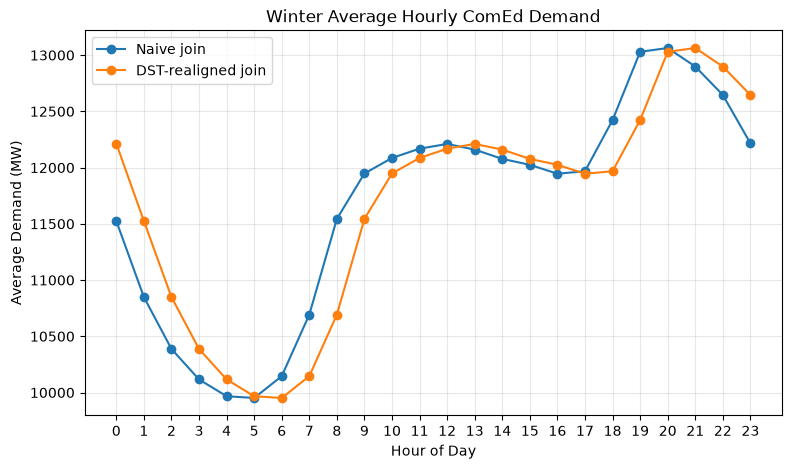

In [40]:
plt.figure(figsize=(9, 5))

plt.plot(
    naive_winter.index,
    naive_winter.values,
    marker="o",
    label="Naive join"
)

plt.plot(
    realigned_winter.index,
    realigned_winter.values,
    marker="o",
    label="DST-realigned join"
)

plt.title("Winter Average Hourly ComEd Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

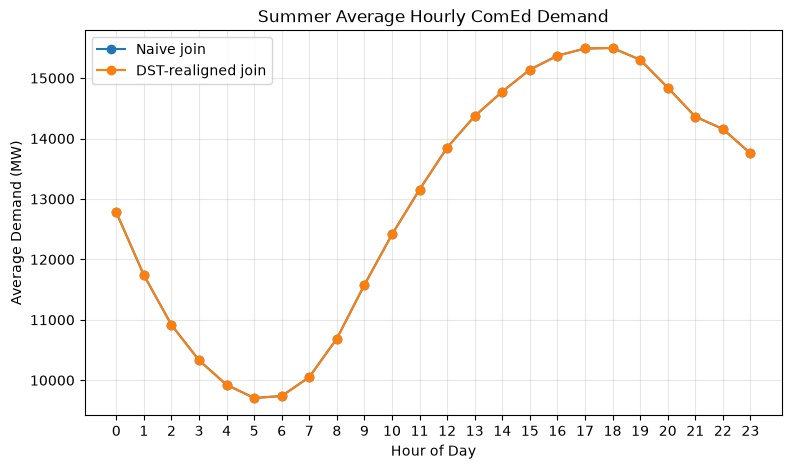

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(
    naive_summer.index,
    naive_summer.values,
    marker="o",
    label="Naive join"
)

plt.plot(
    realigned_summer.index,
    realigned_summer.values,
    marker="o",
    label="DST-realigned join"
)

plt.title("Summer Average Hourly ComEd Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [42]:
winter_unshifted_correlation = np.corrcoef(
    realigned_winter.values,
    naive_winter.values
)[0, 1]

winter_shifted_correlation = np.corrcoef(
    realigned_winter.values,
    np.roll(naive_winter.values, 1)
)[0, 1]

summer_unshifted_correlation = np.corrcoef(
    realigned_summer.values,
    naive_summer.values
)[0, 1]

print(
    "Winter unshifted correlation:",
    round(winter_unshifted_correlation, 4)
)

print(
    "Winter correlation after naive profile is shifted +1 hour:",
    round(winter_shifted_correlation, 4)
)

print(
    "Summer unshifted correlation:",
    round(summer_unshifted_correlation, 4)
)

Winter unshifted correlation: 0.9253
Winter correlation after naive profile is shifted +1 hour: 1.0
Summer unshifted correlation: 1.0


In [43]:
assert (
    winter_shifted_correlation
    > winter_unshifted_correlation
), "Winter does not show the expected one-hour correction."

assert (
    summer_unshifted_correlation > 0.99
), "Summer changed unexpectedly after DST realignment."

print("DST realignment sanity check passed.")

DST realignment sanity check passed.


In [44]:
processed_data_directory.mkdir(
    parents=True,
    exist_ok=True
)

joined_output_path = (
    processed_data_directory
    / "joined_hourly.parquet"
)

joined.to_parquet(
    joined_output_path,
    index=False
)

print("Saved joined dataset to:")
print(joined_output_path)
print("File exists:", joined_output_path.exists())

Saved joined dataset to:
/Users/minhae/Documents/Git/AmpOps/data/processed/joined_hourly.parquet
File exists: True


# EDA

In [112]:
joined_path = processed_data_directory / "joined_hourly.parquet"

eda = pd.read_parquet(joined_path)

print("Dataset shape:", eda.shape)
print("Start:", eda["time"].min())
print("End:", eda["time"].max())

display(eda.head())

Dataset shape: (66493, 32)
Start: 2011-01-01 02:00:00
End: 2018-08-03 00:00:00


,time,COMED_MW,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,snow_depth,snowfall,rain,...,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
0,2011-01-01 02:00:00,9631.0,6.9,98,6.6,2.6,0.2,0.0,0.0,0.2,...,260,41.4,3.8,2.5,1.6,5.7,0.219,0.221,0.186,0.173
1,2011-01-01 03:00:00,9273.0,3.3,90,1.7,-2.1,0.0,0.0,0.0,0.0,...,264,42.5,3.0,2.6,1.6,5.7,0.217,0.220,0.187,0.173
2,2011-01-01 04:00:00,9011.0,0.9,76,-2.9,-5.2,0.0,0.0,0.0,0.0,...,254,42.1,2.2,2.5,1.6,5.7,0.214,0.219,0.187,0.173
3,2011-01-01 05:00:00,8741.0,-0.6,70,-5.4,-6.3,0.0,0.0,0.0,0.0,...,255,42.1,1.3,2.4,1.6,5.7,0.212,0.218,0.188,0.173
4,2011-01-01 06:00:00,8694.0,-2.0,68,-7.0,-7.5,0.0,0.0,0.0,0.0,...,248,40.0,0.6,2.2,1.6,5.7,0.210,0.217,0.188,0.173


In [114]:
# creating local_time so EDA statements refer to actual Chicago time 
fixed_utc_minus_5 = timezone(timedelta(hours=-5))

eda["local_time"] = (
    eda["time"]
    .dt.tz_localize(fixed_utc_minus_5)
    .dt.tz_convert("America/Chicago")
    .dt.tz_localize(None)
)

In [120]:
eda = eda.copy()

eda["year"] = eda["local_time"].dt.year
eda["month"] = eda["local_time"].dt.month
eda["month_name"] = eda["local_time"].dt.month_name().str[:3]
eda["day_of_week"] = eda["local_time"].dt.dayofweek
eda["day_name"] = eda["local_time"].dt.day_name().str[:3]
eda["hour"] = eda["local_time"].dt.hour
eda["date"] = eda["local_time"].dt.date
eda["is_weekend"] = eda["day_of_week"].isin([5, 6])

print(
    eda[
        [
            "time",
            "year",
            "month",
            "month_name",
            "day_of_week",
            "day_name",
            "hour",
            "is_weekend",
        ]
    ].head()
)

                 time  year  month month_name  day_of_week day_name  hour  \
0 2011-01-01 02:00:00  2011      1        Jan            5      Sat     1   
1 2011-01-01 03:00:00  2011      1        Jan            5      Sat     2   
2 2011-01-01 04:00:00  2011      1        Jan            5      Sat     3   
3 2011-01-01 05:00:00  2011      1        Jan            5      Sat     4   
4 2011-01-01 06:00:00  2011      1        Jan            5      Sat     5   

   is_weekend  
0        True  
1        True  
2        True  
3        True  
4        True  


In [121]:
schema_summary = pd.DataFrame({
    "data_type": eda.dtypes.astype(str),
    "missing_count": eda.isna().sum(),
    "unique_values": eda.nunique(),
})

display(schema_summary)

,data_type,missing_count,unique_values
time,datetime64[us],0,66493
COMED_MW,float64,0,10487
temperature_2m,float64,0,602
relative_humidity_2m,int64,0,80
dew_point_2m,float64,0,554
apparent_temperature,float64,0,723
precipitation,float64,0,114
snow_depth,float64,0,32
snowfall,float64,0,26
rain,float64,0,114


In [122]:
non_weather_columns = {
    "time",
    "local_time",
    "COMED_MW",
    "year",
    "month",
    "month_name",
    "day_of_week",
    "day_name",
    "hour",
    "date",
    "is_weekend",
    "is_peak_demand",
    "temperature_bin",
    "season",
}

weather_columns = [
    column
    for column in eda.columns
    if column not in non_weather_columns
]

,COMED_MW
count,66493.000000
mean,11420.341585
std,2304.076173
min,7237.000000
1%,7844.920000
5%,8353.600000
10%,8788.000000
25%,9781.000000
50%,11152.000000
75%,12510.000000


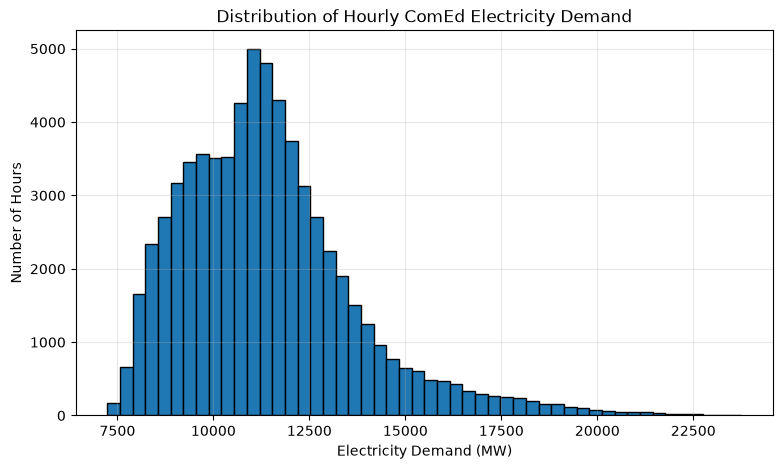

In [123]:
demand_summary = eda["COMED_MW"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(demand_summary.to_frame("COMED_MW"))

plt.figure(figsize=(9, 5))

plt.hist(
    eda["COMED_MW"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Hourly ComEd Electricity Demand")
plt.xlabel("Electricity Demand (MW)")
plt.ylabel("Number of Hours")
plt.grid(alpha=0.3)
plt.show()

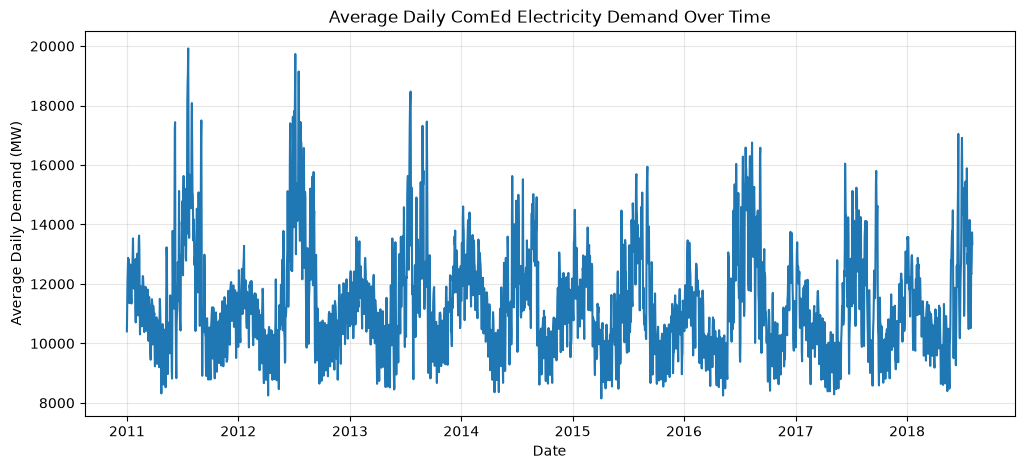

In [124]:
daily_demand = (
    eda
    .set_index("time")["COMED_MW"]
    .resample("D")
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(daily_demand.index, daily_demand.values)

plt.title("Average Daily ComEd Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Average Daily Demand (MW)")
plt.grid(alpha=0.3)
plt.show()

,mean,median,min,max,std,count
year,,,,,,
2011,11648.486240,11389.0,7504.0,23753.0,2462.454166,8757
2012,11612.159645,11240.5,7382.0,23603.0,2643.829178,8782
2013,11549.350879,11391.0,7394.0,22269.0,2240.878386,8758
2014,11440.276002,11255.0,7237.0,19721.0,2034.879276,8759
2015,11179.113769,10984.0,7376.0,20162.0,2116.513760,8759
2016,11434.651827,11014.0,7290.0,21175.0,2428.142947,8783
2017,11046.054458,10855.0,7263.0,20351.0,2102.845849,8759
2018,11474.611565,11187.5,7418.0,21349.0,2244.174915,5136


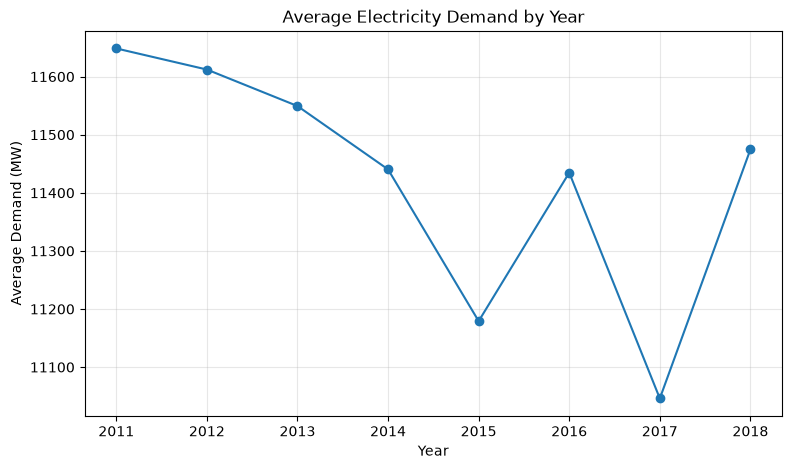

In [125]:
yearly_demand = (
    eda
    .groupby("year")["COMED_MW"]
    .agg(["mean", "median", "min", "max", "std", "count"])
)

display(yearly_demand)

plt.figure(figsize=(9, 5))

plt.plot(
    yearly_demand.index,
    yearly_demand["mean"],
    marker="o"
)

plt.title("Average Electricity Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Demand (MW)")
plt.xticks(yearly_demand.index)
plt.grid(alpha=0.3)
plt.show()

,mean,median,std,count
hour,,,,
0,11271.850595,10878.0,1696.623045,2771
1,10487.464453,10157.0,1515.727237,2771
2,9915.379710,9645.0,1373.566094,2760
3,9540.787802,9305.0,1269.482133,2771
4,9304.747023,9084.0,1198.934007,2771
5,9215.146157,9020.0,1160.697198,2771
6,9347.616023,9148.0,1155.871777,2771
7,9816.180079,9645.0,1230.183934,2771
8,10578.081198,10477.0,1435.510892,2771


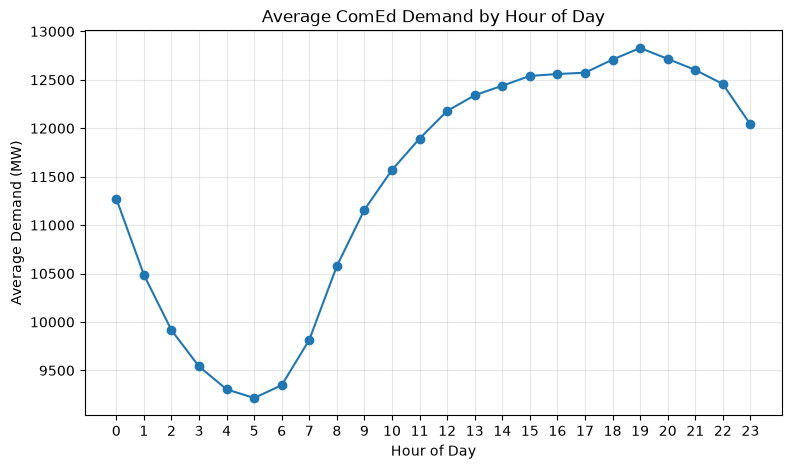

In [126]:
hourly_demand = (
    eda
    .groupby("hour")["COMED_MW"]
    .agg(["mean", "median", "std", "count"])
)

display(hourly_demand)

plt.figure(figsize=(9, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand["mean"],
    marker="o"
)

plt.title("Average ComEd Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()

In [127]:
lowest_hour = hourly_demand["mean"].idxmin()
highest_hour = hourly_demand["mean"].idxmax()

print("Lowest average-demand hour:", lowest_hour)
print("Highest average-demand hour:", highest_hour)

Lowest average-demand hour: 5
Highest average-demand hour: 19


,average_COMED_MW
day_name,
Mon,11668.309659
Tue,11913.074495
Wed,11898.029146
Thu,11837.419402
Fri,11670.546356
Sat,10699.195728
Sun,10254.997156


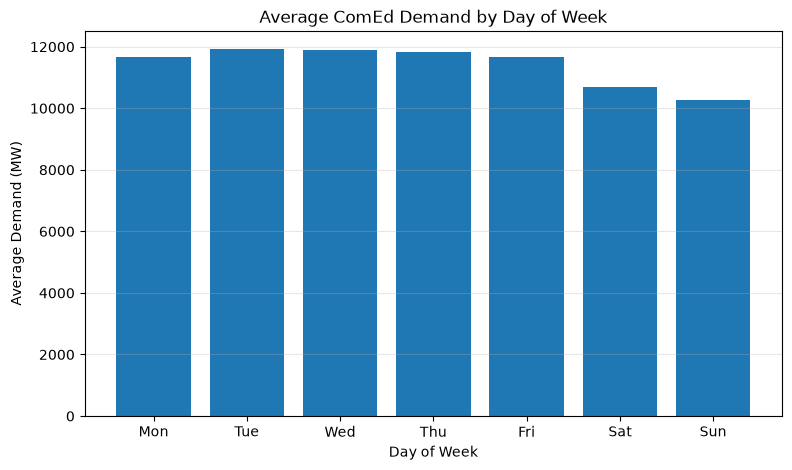

In [128]:
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

day_of_week_demand = (
    eda
    .groupby("day_name")["COMED_MW"]
    .mean()
    .reindex(day_order)
)

display(day_of_week_demand.to_frame("average_COMED_MW"))
plt.figure(figsize=(9, 5))

plt.bar(
    day_of_week_demand.index,
    day_of_week_demand.values
)

plt.title("Average ComEd Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand (MW)")
plt.grid(axis="y", alpha=0.3)
plt.show()

,mean,median,std,count
is_weekend,,,,
Weekday,11797.537276,11508.0,2329.341137,47497
Weekend,10477.213361,10063.0,1941.915548,18996


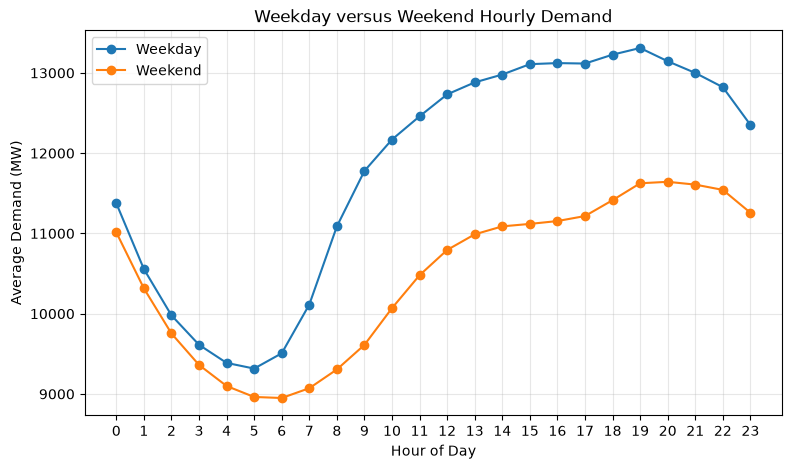

In [129]:
weekday_weekend_summary = (
    eda
    .groupby("is_weekend")["COMED_MW"]
    .agg(["mean", "median", "std", "count"])
    .rename(index={False: "Weekday", True: "Weekend"})
)

display(weekday_weekend_summary)

weekday_hourly = (
    eda[~eda["is_weekend"]]
    .groupby("hour")["COMED_MW"]
    .mean()
)

weekend_hourly = (
    eda[eda["is_weekend"]]
    .groupby("hour")["COMED_MW"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.plot(
    weekday_hourly.index,
    weekday_hourly.values,
    marker="o",
    label="Weekday"
)

plt.plot(
    weekend_hourly.index,
    weekend_hourly.values,
    marker="o",
    label="Weekend"
)

plt.title("Weekday versus Weekend Hourly Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

,mean,median,max,std,count
month_name,,,,,
Jan,11950.614855,12033.0,16514.0,1471.412178,5951
Feb,11625.380162,11677.5,15279.0,1408.386902,5424
Mar,10734.586642,10822.5,14466.0,1269.477984,5944
Apr,9995.937847,10079.5,12745.0,1207.273318,5760
May,10435.957325,10333.0,18397.0,1930.643338,5952
Jun,12176.685243,11799.0,22830.0,2755.717579,5760
Jul,13564.192540,13149.0,23753.0,3212.452604,5952
Aug,12987.270687,12700.0,22576.0,2805.815423,5257
Sep,11386.256944,11067.0,21900.0,2590.412597,5040


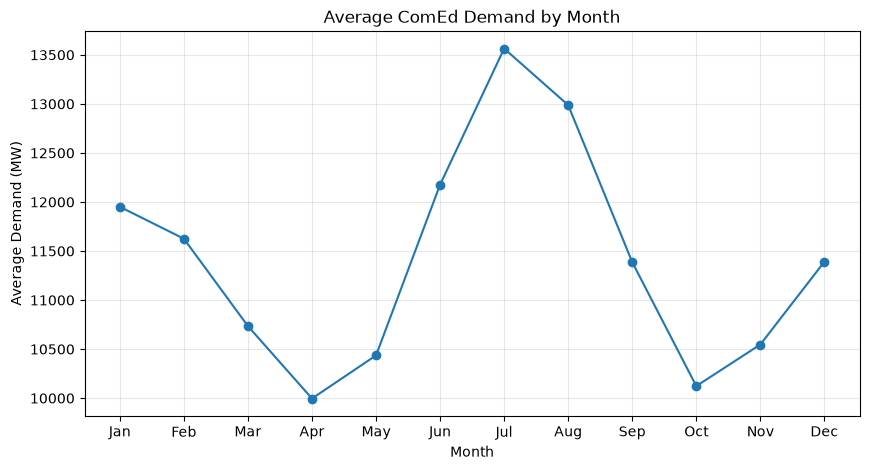

In [130]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_demand = (
    eda
    .groupby("month_name")["COMED_MW"]
    .agg(["mean", "median", "max", "std", "count"])
    .reindex(month_order)
)

display(monthly_demand)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand["mean"],
    marker="o"
)

plt.title("Average ComEd Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.grid(alpha=0.3)
plt.show()

In [131]:
temperature_candidates = [
    column
    for column in eda.columns
    if "temperature_2m" in column.lower()
    and "soil" not in column.lower()
]

print("Temperature candidates:", temperature_candidates)
if not temperature_candidates:
    raise ValueError("No air-temperature column was found.")

temperature_column = temperature_candidates[0]

print("Using temperature column:", temperature_column)

humidity_candidates = [
    column
    for column in eda.columns
    if "relative_humidity" in column.lower()
]

dew_point_candidates = [
    column
    for column in eda.columns
    if "dew_point" in column.lower()
]

humidity_column = (
    humidity_candidates[0]
    if humidity_candidates
    else None
)

dew_point_column = (
    dew_point_candidates[0]
    if dew_point_candidates
    else None
)

print("Humidity column:", humidity_column)
print("Dew-point column:", dew_point_column)

Temperature candidates: ['temperature_2m']
Using temperature column: temperature_2m
Humidity column: relative_humidity_2m
Dew-point column: dew_point_2m


,temperature_2m
count,66493.000000
mean,10.128059
std,11.091591
min,-25.400000
1%,-15.900000
5%,-8.200000
25%,1.600000
50%,10.200000
75%,19.700000
95%,26.200000


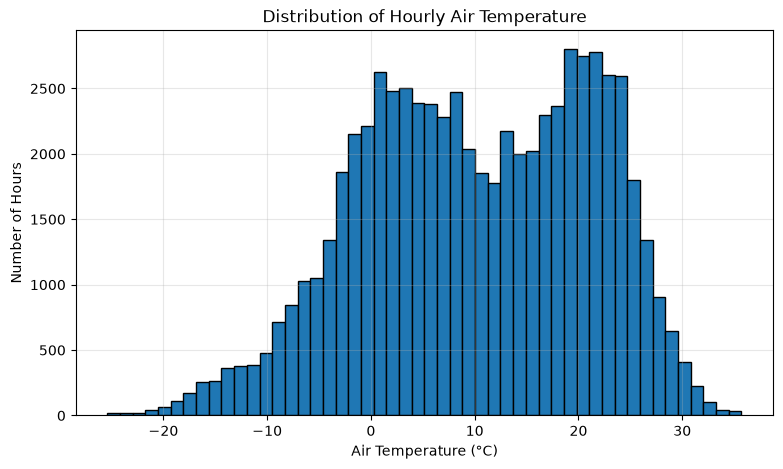

In [132]:
display(
    eda[temperature_column]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .to_frame(temperature_column)
)
plt.figure(figsize=(9, 5))

plt.hist(
    eda[temperature_column],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Hourly Air Temperature")
plt.xlabel("Air Temperature (°C)")
plt.ylabel("Number of Hours")
plt.grid(alpha=0.3)
plt.show()

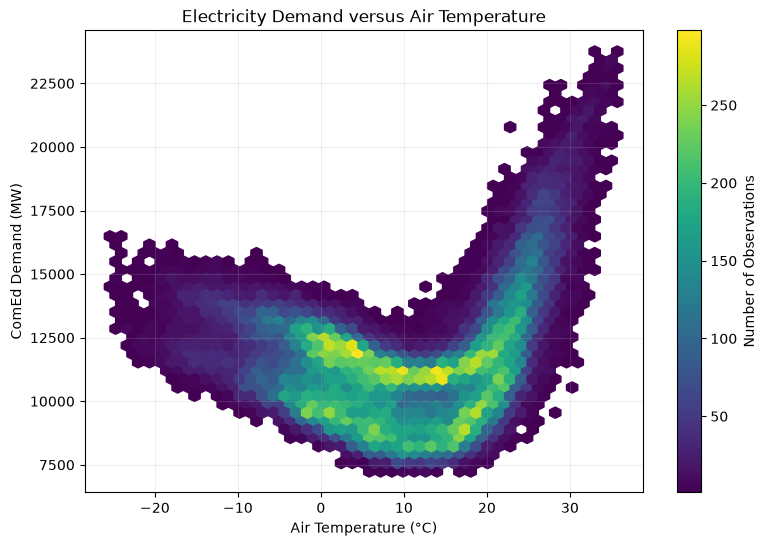

In [133]:
plt.figure(figsize=(9, 6))

hexbin_plot = plt.hexbin(
    eda[temperature_column],
    eda["COMED_MW"],
    gridsize=45,
    mincnt=1
)

plt.colorbar(
    hexbin_plot,
    label="Number of Observations"
)

plt.title("Electricity Demand versus Air Temperature")
plt.xlabel("Air Temperature (°C)")
plt.ylabel("ComEd Demand (MW)")
plt.grid(alpha=0.2)
plt.show()

,mean,median,count
temperature_bin,,,
-25.0,13374.946903,12965.0,113
-20.0,12979.554167,12776.0,720
-15.0,12794.070968,12929.5,1550
-10.0,12054.311812,12099.0,3454
-5.0,11334.080578,11315.0,7471
0.0,10836.135777,10919.0,10079
5.0,10084.167216,10157.5,9404
10.0,9844.073623,9836.0,7973
15.0,10403.439145,10338.0,9687


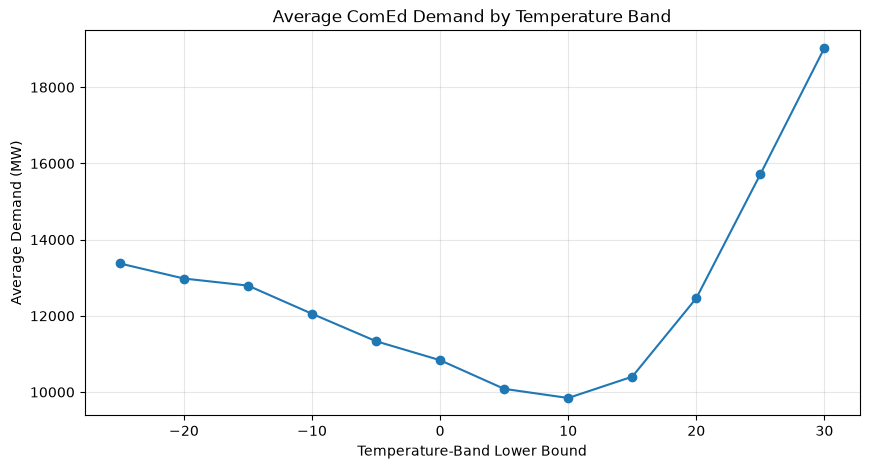

In [134]:
eda["temperature_bin"] = (
    np.floor(eda[temperature_column] / 5) * 5
)

temperature_bin_summary = (
    eda
    .groupby("temperature_bin", observed=True)["COMED_MW"]
    .agg(["mean", "median", "count"])
    .query("count >= 50")
)

display(temperature_bin_summary)

plt.figure(figsize=(10, 5))

plt.plot(
    temperature_bin_summary.index,
    temperature_bin_summary["mean"],
    marker="o"
)

plt.title("Average ComEd Demand by Temperature Band")
plt.xlabel("Temperature-Band Lower Bound")
plt.ylabel("Average Demand (MW)")
plt.grid(alpha=0.3)
plt.show()

,correlation_with_COMED_MW
soil_moisture_0_to_7cm,-0.260813
relative_humidity_2m,-0.238372
soil_moisture_7_to_28cm,-0.224827
soil_moisture_28_to_100cm,-0.167212
wind_speed_100m,-0.111170
cloud_cover_low,-0.064456
soil_moisture_100_to_255cm,-0.055170
wind_speed_10m,-0.046912
pressure_msl,-0.046056
cloud_cover_mid,-0.036647


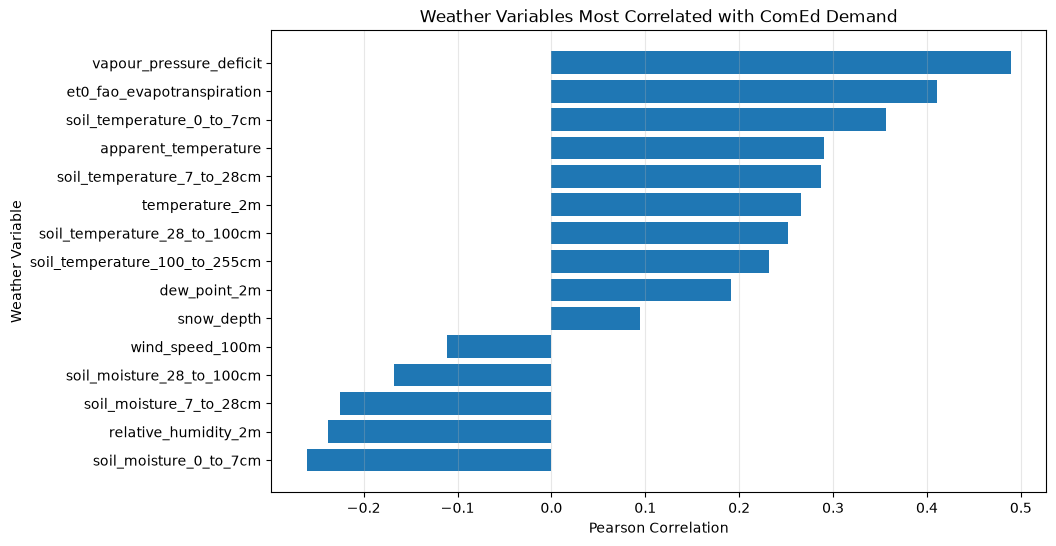

In [135]:
numeric_weather_columns = [
    column
    for column in weather_columns
    if pd.api.types.is_numeric_dtype(eda[column])
]

weather_demand_correlations = (
    eda[
        ["COMED_MW"] + numeric_weather_columns
    ]
    .corr(numeric_only=True)["COMED_MW"]
    .drop("COMED_MW")
    .sort_values()
)

display(
    weather_demand_correlations.to_frame(
        "correlation_with_COMED_MW"
    )
)

top_correlation_columns = (
    weather_demand_correlations
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

top_correlations = (
    weather_demand_correlations
    .loc[top_correlation_columns]
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_correlations.index,
    top_correlations.values
)

plt.title("Weather Variables Most Correlated with ComEd Demand")
plt.xlabel("Pearson Correlation")
plt.ylabel("Weather Variable")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [136]:
selected_weather_columns = [
    column
    for column in [
        temperature_column,
        humidity_column,
        dew_point_column,
    ]
    if column is not None
]

selected_weather_correlations = (
    eda[selected_weather_columns]
    .corr(numeric_only=True)
)

display(selected_weather_correlations)

,temperature_2m,relative_humidity_2m,dew_point_2m
temperature_2m,1.000000,-0.016564,0.962457
relative_humidity_2m,-0.016564,1.000000,0.252520
dew_point_2m,0.962457,0.252520,1.000000


In [137]:
peak_threshold = eda["COMED_MW"].quantile(0.90)

eda["is_peak_demand"] = (
    eda["COMED_MW"] >= peak_threshold
)

print("90th-percentile demand threshold:", peak_threshold)
print("Peak-demand hours:", eda["is_peak_demand"].sum())
print(
    "Peak-demand share:",
    eda["is_peak_demand"].mean()
)

90th-percentile demand threshold: 14254.800000000003
Peak-demand hours: 6650
Peak-demand share: 0.10001052742393936


In [138]:
peak_summary_columns = [
    "COMED_MW",
    temperature_column,
]

if humidity_column is not None:
    peak_summary_columns.append(humidity_column)

peak_comparison = (
    eda
    .groupby("is_peak_demand")[peak_summary_columns]
    .mean()
    .rename(index={
        False: "Non-peak hours",
        True: "Peak hours",
    })
)

display(peak_comparison)

,COMED_MW,temperature_2m,relative_humidity_2m
is_peak_demand,,,
Non-peak hours,10868.554752,8.688258,74.475344
Peak hours,16385.842256,23.084752,67.854286


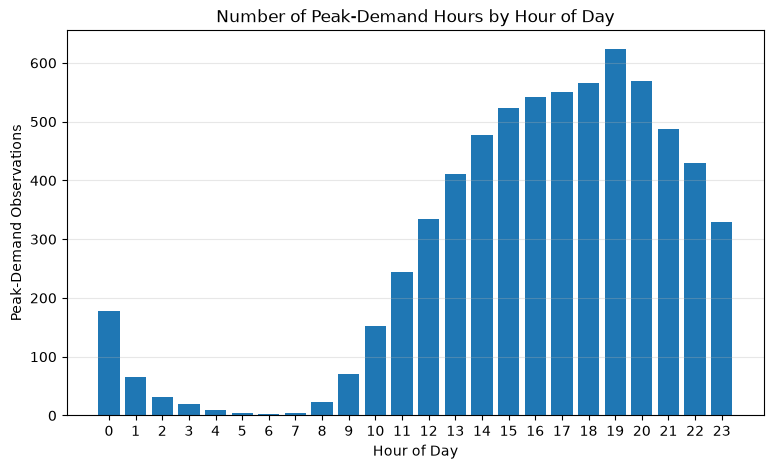

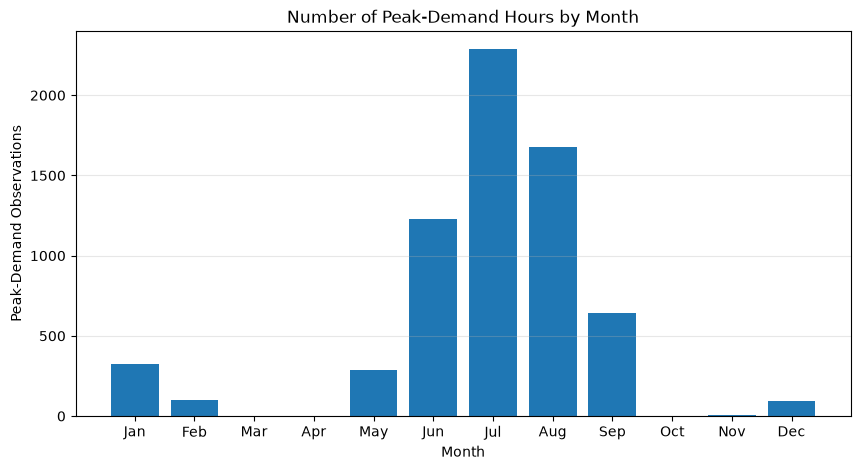

In [139]:
peak_by_hour = (
    eda[eda["is_peak_demand"]]
    .groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(9, 5))

plt.bar(
    peak_by_hour.index,
    peak_by_hour.values
)

plt.title("Number of Peak-Demand Hours by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Peak-Demand Observations")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.show()

peak_by_month = (
    eda[eda["is_peak_demand"]]
    .groupby("month_name")
    .size()
    .reindex(month_order, fill_value=0)
)

plt.figure(figsize=(10, 5))

plt.bar(
    peak_by_month.index,
    peak_by_month.values
)

plt.title("Number of Peak-Demand Hours by Month")
plt.xlabel("Month")
plt.ylabel("Peak-Demand Observations")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [140]:
top_demand_columns = [
    "time",
    "COMED_MW",
    temperature_column,
    "hour",
    "day_name",
    "month_name",
    "is_weekend",
]

if humidity_column is not None:
    top_demand_columns.append(humidity_column)

top_demand_events = (
    eda
    .nlargest(20, "COMED_MW")
    [top_demand_columns]
)

display(top_demand_events)

,time,COMED_MW,temperature_2m,hour,day_name,month_name,is_weekend,relative_humidity_2m
4816,2011-07-20 18:00:00,23753.0,35.3,18,Wed,Jul,False,55
4815,2011-07-20 17:00:00,23713.0,35.4,17,Wed,Jul,False,55
4839,2011-07-21 17:00:00,23670.0,33.6,17,Thu,Jul,False,61
13261,2012-07-06 17:00:00,23603.0,34.8,17,Fri,Jul,False,58
4838,2011-07-21 16:00:00,23587.0,33.6,16,Thu,Jul,False,60
4817,2011-07-20 19:00:00,23582.0,34.8,19,Wed,Jul,False,56
4840,2011-07-21 18:00:00,23542.0,33.6,18,Thu,Jul,False,62
13260,2012-07-06 16:00:00,23533.0,34.9,16,Fri,Jul,False,56
4814,2011-07-20 16:00:00,23524.0,35.1,16,Wed,Jul,False,57
13262,2012-07-06 18:00:00,23516.0,34.5,18,Fri,Jul,False,60


In [141]:
lag_correlations = {
    "Previous hour (t-1)": eda["COMED_MW"].corr(
        eda["COMED_MW"].shift(1)
    ),
    "Previous day (t-24)": eda["COMED_MW"].corr(
        eda["COMED_MW"].shift(24)
    ),
    "Previous week (t-168)": eda["COMED_MW"].corr(
        eda["COMED_MW"].shift(168)
    ),
}

lag_correlation_table = pd.Series(
    lag_correlations,
    name="correlation"
).to_frame()

display(lag_correlation_table)

,correlation
Previous hour (t-1),0.978984
Previous day (t-24),0.853392
Previous week (t-168),0.733260


### EDA Findings

- The final joined dataset contains 66,493 hourly observations with no duplicate timestamps or null values in matched rows
- ComEd demand ranges from 7,237 to 23,753 MW, averaging 11,420 MW
- Demand shows strong hourly, weekly, and monthly seasonality; weekdays average 11,795 MW, about 12.5% higher than weekends
- Demand is highest in summer, especially July, and lowest during milder spring and fall months
- Temperature has a clear U-shaped relationship with demand: usage rises during both cold and hot weather, but the increase is much stronger during extreme heat
- The top 10% of demand begins at approximately 14,255 MW and is concentrated in summer afternoons and evenings, particularly July
- Peak hours average approximately 23.1°C, compared with 8.7°C during non-peak hours; the highest-demand events occurred on very hot July weekdays
- Temperature and dew point are highly correlated (0.96), indicating potential feature redundancy
- Demand is strongly related to its history: correlations are 0.98 at t−1, 0.85 at t−24, and 0.73 at t−168, supporting the proposed lag features